# Simple-BEV lifting, step by step 🧭
### "Ask every voxel which pixel sees it", the simplest lifter that works

**Lifter name in the repo:** `simple_bev` · **class:** `BilinearSamplingLifter` · **paper:** *Simple-BEV* (Harley et al., 2023)

Lifting means turning 2D image features into a 3D / bird's-eye-view (BEV) feature map. Simple-BEV does it with **zero learned
parameters in the lifting step**:

1. take the centre of every voxel in a 3D grid,
2. **project** it into every camera (plain geometry),
3. **read the image feature** at that pixel (bilinear interpolation),
4. **average** over the cameras that see the voxel,
5. fold the height axis into channels and compress it with a conv.

| Step | Question |
|---|---|
| 0 | Setup and data |
| 1 | The idea: pull instead of push |
| 2 | Project the voxel centres into the cameras |
| 3 | Read features with bilinear sampling (with an exact test) |
| 4 | Average over cameras that can see the voxel |
| 5 | Visual: what happens when you lift without any depth? |
| 6 | Fold height away: the `HeightCompressor` |
| 7 | The complete lifter, shape by shape |
| 8 | Train and test it |
| 9 | Pros, cons, exercises |

## Step 0: Setup and the data

> New to this repo? The notebook `tpv_lifting_step_by_step.ipynb` explains `GridSpec`, `Cameras` and the synthetic
> data in more detail. Here is the short version.

* **Ego frame:** `x` forward, `y` left, `z up` (metres). A `GridSpec` chops a box of the world into cells.
* **Cameras:** `cameras.project(points)` maps 3D ego points to pixels `(u, v)` and a depth `d`
  (*easy direction*). Going back from a pixel needs the depth (*hard direction*).
* **Data:** procedurally rendered street scenes with 4 cameras, red *vehicles* and blue *pedestrians*.
  The task is **BEV semantic segmentation**: predict the top-down class map (`0` empty, `1` vehicle, `2` pedestrian)
  from the 4 images alone. The whole camera rig is randomly rotated in every scene, so the network *has to use the calibration*.

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)
from lifting.lifters import BilinearSamplingLifter
from lifting.ops import sample_multi_camera, masked_camera_mean
from lifting.layers import HeightCompressor

torch 2.14.1


images: (4, 4, 3, 48, 96) = (B, N cameras, 3, H, W)
BEV labels: (4, 32, 32) = (B, X, Y)


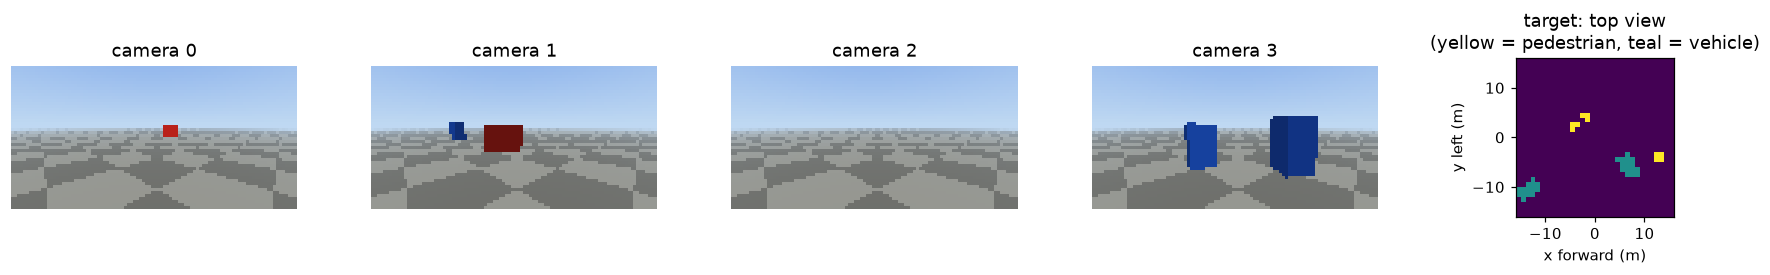

In [2]:
grid = GridSpec(resolution=(32, 32, 4))          # 32 x 32 x 4 cells of 1 m^3 over a 32 m x 32 m x 4 m box
data = SyntheticSceneDataset(256, grid, seed=1)
batch = SceneBatch.collate([data[i] for i in range(4)])
cams = batch.cameras
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]
print("images:", tuple(batch.images.shape), "= (B, N cameras, 3, H, W)")
print("BEV labels:", tuple(batch.bev_labels.shape), "= (B, X, Y)")

fig, ax = plt.subplots(1, 5, figsize=(16, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[4].set_title("target: top view\n(yellow = pedestrian, teal = vehicle)"); ax[4].set_xlabel("x forward (m)"); ax[4].set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

## Step 1: The big idea: *pull* instead of *push*

There are two ways to connect a 2D image and a 3D grid.

| | **Push** (forward) | **Pull** (backward / inverse) |
|---|---|---|
| loop over | pixels | voxels |
| needs | the depth of every pixel (to know *where* to put it) | nothing but the camera matrices |
| result | can leave **holes** or need depth guesses | every voxel gets a value (if some camera sees it) |
| example | Lift-Splat-Shoot | **Simple-BEV** (this notebook) |

Pulling works because projecting a 3D point into an image is *well defined* (one point → one pixel), whereas un-projecting
a pixel is *ambiguous* (one pixel → a whole ray).

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg

### 🖼️ Diagram: pull vs push
Left: the **pull** idea used here (each voxel finds *its* pixel). Right: the **push** idea of Lift-Splat (each pixel must guess its depth).
Top-down view: the camera looks up, the green segment is the image plane, grey cells are the voxel grid.

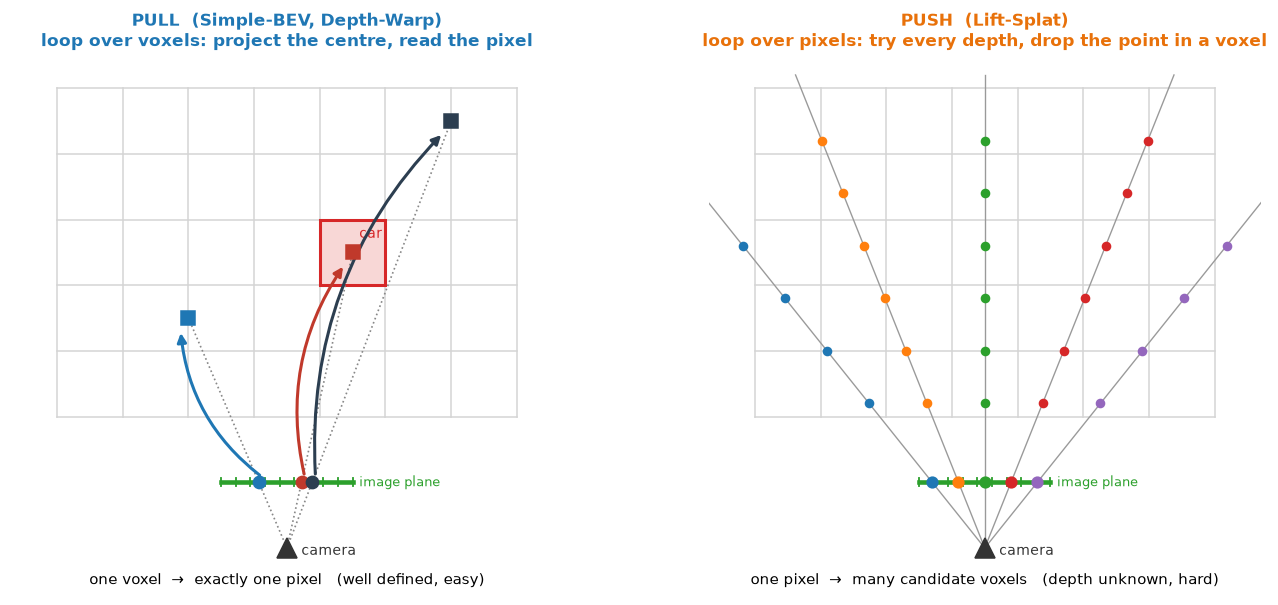

In [4]:
dg.fig_pull_vs_push()

## Step 2: Project all voxel centres into the cameras

`grid.voxel_centers()` gives the metric `(x, y, z)` of every voxel. `cameras.project` returns for every camera:
the pixel `uv`, the `depth` and a `valid` flag (in front of the camera **and** inside the image).

In [5]:
centers = grid.voxel_centers()                                   # (X, Y, Z, 3)
points = centers.view(1, -1, 3).expand(cams.batch_size, -1, -1)  # (B, P=X*Y*Z, 3)
uv, depth, valid = cams.project(points)
print("voxel centres :", tuple(points.shape), "= (B, P, 3)")
print("uv            :", tuple(uv.shape), "= (B, N, P, 2)")
print("valid         :", tuple(valid.shape), "-> fraction of voxels each camera sees:", valid[0].float().mean(1).tolist())

voxel centres : (4, 4096, 3) = (B, P, 3)
uv            : (4, 4, 4096, 2) = (B, N, P, 2)
valid         : (4, 4, 4096) -> fraction of voxels each camera sees: [0.268798828125, 0.268798828125, 0.268798828125, 0.268798828125]


Each camera sees only its own wedge of the world. Left: the voxel centres that land inside camera 0's image (coloured by depth).
Right: for each BEV cell, **how many cameras see it** (taken at one height). Because the cameras overlap, some cells are seen twice.

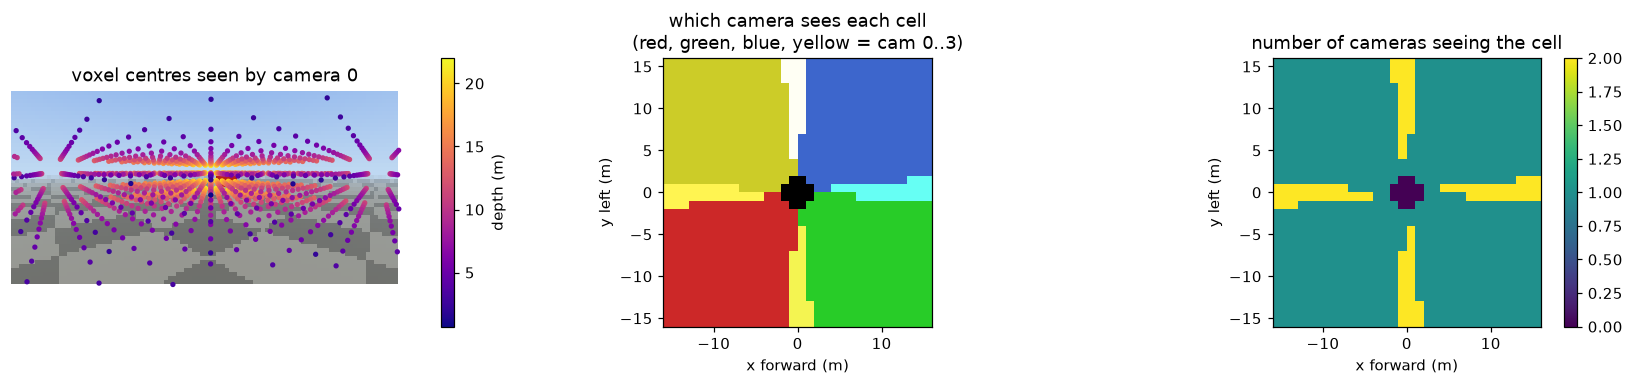

In [6]:
vol_valid = valid.view(cams.batch_size, cams.num_cameras, *grid.resolution)       # (B, N, X, Y, Z)
count = vol_valid.sum(1)                                                          # (B, X, Y, Z)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
v0 = valid[0, 0]
ax[0].imshow(batch.images[0, 0].permute(1, 2, 0))
sc = ax[0].scatter(uv[0, 0, v0, 0], uv[0, 0, v0, 1], c=depth[0, 0, v0], s=6, cmap="plasma")
plt.colorbar(sc, ax=ax[0], fraction=0.046, label="depth (m)"); ax[0].set_title("voxel centres seen by camera 0"); ax[0].axis("off")

cam_map = vol_valid[0, :, :, :, 1].float()                                        # (N, X, Y) at z index 1
cols = torch.zeros(*cam_map.shape[1:], 3)
palette = torch.tensor([[1, .2, .2], [.2, 1, .2], [.3, .5, 1], [1, 1, .2]])
for n in range(4): cols += cam_map[n][..., None] * palette[n] * 0.8
ax[1].imshow(cols.clamp(0, 1).permute(1, 0, 2), origin="lower", extent=ext); ax[1].set_title("which camera sees each cell\n(red, green, blue, yellow = cam 0..3)")
im = ax[2].imshow(count[0, :, :, 1].T, origin="lower", extent=ext, cmap="viridis"); plt.colorbar(im, ax=ax[2], fraction=0.046)
ax[2].set_title("number of cameras seeing the cell")
for a in ax[1:]: a.set_xlabel("x forward (m)"); a.set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

Cells right next to the car (or beyond the field of view) may be seen by **no** camera; they receive a feature of exactly 0.

## Step 3: Read image features at the projected pixels

`sample_multi_camera(features, uv_normalized)` wraps `F.grid_sample`: for each camera it reads the feature map at the
(sub-pixel) location with **bilinear interpolation**, i.e. a weighted average of the 4 nearest pixels.

Does it read the *right* pixel? We can test that exactly, with an **analytic probe** (the same trick the repo's tests use):
make a feature map that simply *stores its own pixel coordinates*, `ch0 = u/W`, `ch1 = v/H`. Then sampling at the projection of a
voxel must give back that very `(u/W, v/H)`.

In [7]:
B, N = cams.batch_size, cams.num_cameras
H, W = cams.image_size
vv, uu = torch.meshgrid((torch.arange(H) + 0.5) / H, (torch.arange(W) + 0.5) / W, indexing="ij")   # pixel centres in [0, 1]
ramp = torch.stack([uu, vv]).expand(B, N, 2, H, W).contiguous()                                    # (B, N, 2, H, W)

uv_n = cams.normalize_uv(uv)                          # (B, N, P, 2) in [0, 1]
sampled = sample_multi_camera(ramp, uv_n)             # (B, N, 2, P)

# compare on voxels that project at least one pixel away from the image border
inner = valid & (uv[..., 0] > 1) & (uv[..., 0] < W - 1) & (uv[..., 1] > 1) & (uv[..., 1] < H - 1)
err = (sampled.permute(0, 1, 3, 2) - uv_n).abs()[inner]
print(f"checked {inner.sum().item()} (voxel, camera) pairs; max error = {err.max().item():.2e}")
assert err.max() < 1e-4
print("✓ sampling returns the feature of exactly the pixel the voxel projects to")

checked 17512 (voxel, camera) pairs; max error = 1.19e-07
✓ sampling returns the feature of exactly the pixel the voxel projects to


## Step 4: Average over the cameras that see the voxel

A voxel can be visible in 0, 1 or 2+ cameras. `masked_camera_mean(values, valid)` averages only over the cameras with `valid = True`
(and divides by at least 1, so unseen voxels become 0 instead of `NaN`). Tiny example:

In [8]:
vals  = torch.tensor([[[[10., 20., 30.]],      # camera 0 reads these values for 3 voxels (1 channel)
                       [[ 2.,  4.,  6.]]]])    # camera 1
mask  = torch.tensor([[[True, True, False],    # camera 0 sees voxels 0,1
                       [False, True, False]]]) # camera 1 sees voxel 1 only
print("values  (B,N,C,P):", tuple(vals.shape))
print("result           :", masked_camera_mean(vals, mask).flatten().tolist())
print("voxel 0 <- cam 0 only          = 10")
print("voxel 1 <- mean(20, 4)         = 12")
print("voxel 2 <- nobody sees it      =  0")

values  (B,N,C,P): (1, 2, 1, 3)
result           : [10.0, 12.0, 0.0]
voxel 0 <- cam 0 only          = 10
voxel 1 <- mean(20, 4)         = 12
voxel 2 <- nobody sees it      =  0


## Step 5: Seeing the limitation: lifting *without* depth

The pull method copies a pixel's feature to **every voxel along the ray that projects onto that pixel**: it has no idea how far away the object is.

Let's see this with the simplest feature: a 1-channel mask that is `1` on red (vehicle) pixels and `0` elsewhere.
We lift it with the library's `unproject` (using one camera at a time) and look at the result from above.

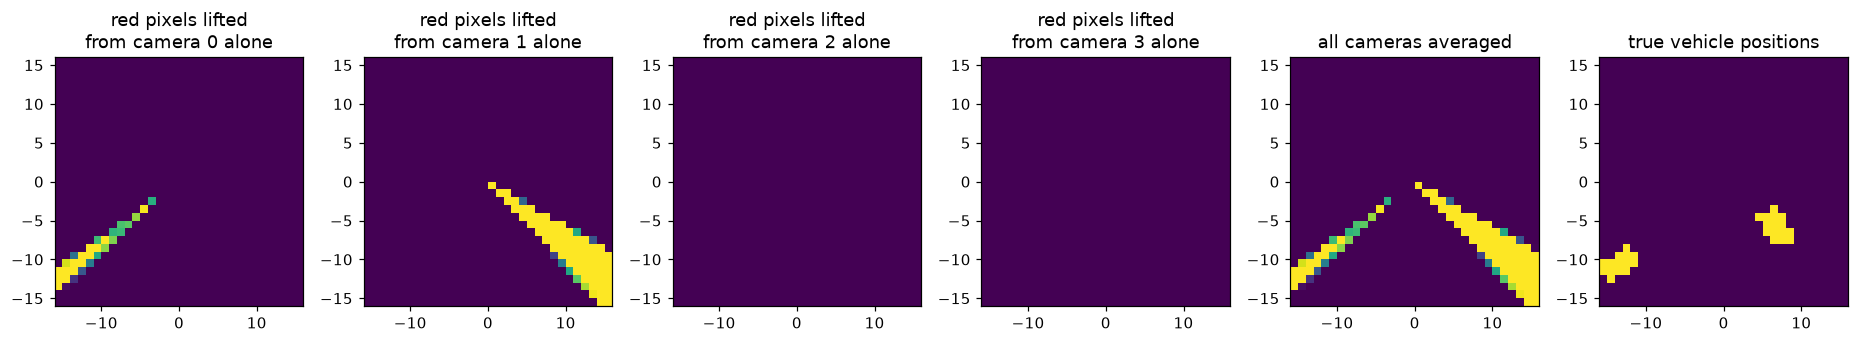

In [9]:
img = batch.images                                               # (B, N, 3, H, W)
r, g, b_ = img[:, :, 0], img[:, :, 1], img[:, :, 2]
red = ((r - torch.maximum(g, b_)) > 0.25).float()[:, :, None]    # (B, N, 1, H, W) vehicle-coloured pixels

lifter1 = BilinearSamplingLifter(grid, in_channels=1, out_channels=1)
def one_cam(n):
    return Cameras(cams.intrinsics[:, n:n+1], cams.cam_to_ego[:, n:n+1], cams.image_size)

s = 0
per_cam = [lifter1.unproject(red[:, n:n+1], one_cam(n))[s, 0].amax(-1) for n in range(4)]   # (X, Y) each, max over height
both = lifter1.unproject(red, cams)[s, 0].amax(-1)

fig2, ax2 = plt.subplots(1, 6, figsize=(17, 3))
for n in range(4):
    ax2[n].imshow(per_cam[n].T, origin="lower", extent=ext); ax2[n].set_title(f"red pixels lifted\nfrom camera {n} alone")
ax2[4].imshow(both.T, origin="lower", extent=ext); ax2[4].set_title("all cameras averaged")
ax2[5].imshow((batch.bev_labels[s] == 1).T, origin="lower", extent=ext); ax2[5].set_title("true vehicle positions")
plt.tight_layout(); plt.show()

**What you see:** from a single camera the vehicle becomes a **streak (a ray)** from the camera outwards: the lifter cannot tell
where along the ray the vehicle is. Averaging several cameras helps wherever their rays cross, but the average also dilutes it.

Simple-BEV does **not** fix this in the lifter. Instead it relies on the **learned part**: the image encoder can encode
"I am a car that is *this big*" (apparent size → distance), and the BEV decoder (a U-Net) cleans up the streaks using context.
Methods in the other notebooks (`depth_warp`, `lift_splat`) add an explicit depth distribution instead.

## Step 6: Fold the height away: `HeightCompressor`

The pulled volume is `(B, C, X, Y, Z)`. The final output is a BEV map, so the `Z` layers are stacked **into the channel axis**
(`C·Z` channels) and mixed by a 3×3 conv + 1×1 conv. The network learns what a given height means (ground vs. car roof vs. sky).

In [10]:
comp = HeightCompressor(in_channels=32, height=4, out_channels=32)
vol = torch.randn(2, 32, 32, 32, 4)
bev = comp(vol)
print("volume", tuple(vol.shape), "-> BEV", tuple(bev.shape))
print("conv input channels = C * Z =", 32 * 4)
print("compressor parameters:", f"{sum(p.numel() for p in comp.parameters()):,}")

volume (2, 32, 32, 32, 4) -> BEV (2, 32, 32, 32)
conv input channels = C * Z = 128
compressor parameters: 37,984


## Step 7: The complete lifter, shape by shape

`BilinearSamplingLifter.forward(features, cameras)`:

```python
voxel_feats = self.unproject(features[level], cameras)   # Steps 2-4: (B, C, X, Y, Z), no parameters
return self.compressor(voxel_feats)                       # Step 6:   (B, C, X, Y)
```
We feed it real features from the image encoder:

### 🖼️ Diagram: the whole Simple-BEV lifter
Purple boxes contain learned weights; blue boxes are pure geometry or fixed maths. Almost the entire lifting step is the blue part.

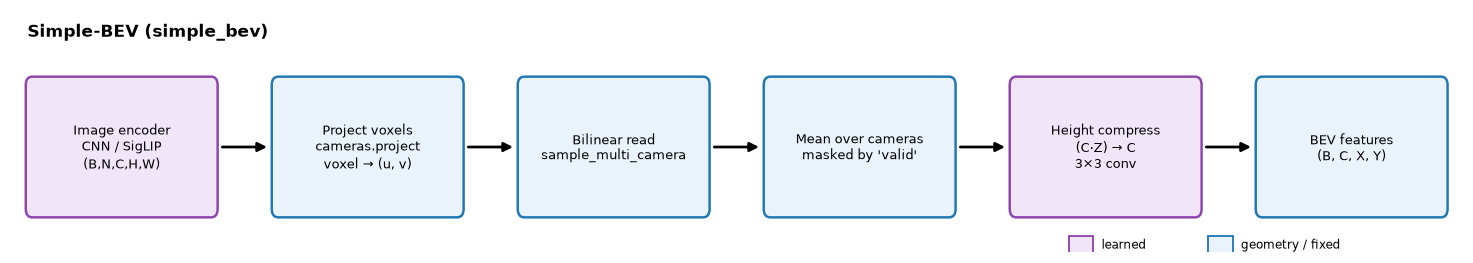

In [11]:
dg.pipeline([('Image encoder', 'CNN / SigLIP\n(B,N,C,H,W)'), ('Project voxels', 'cameras.project\nvoxel → (u, v)'), ('Bilinear read', 'sample_multi_camera'), ('Mean over cameras', "masked by 'valid'"), ('Height compress', '(C·Z) → C\n3×3 conv'), ('BEV features', '(B, C, X, Y)')], 'Simple-BEV (simple_bev)', learned=(0, 4))

In [12]:
from lifting.encoders import SimpleConvEncoder
enc = SimpleConvEncoder(out_channels=32, num_levels=2)
with torch.no_grad():
    feats = [f.view(4, 4, *f.shape[1:]) for f in enc(batch.images.flatten(0, 1))]
print("pyramid:", [tuple(f.shape) for f in feats], "= (B, N, C, H_l, W_l)")

lifter = BilinearSamplingLifter(grid, in_channels=32, out_channels=32, level=0)
with torch.no_grad():
    cams_l0 = cams.scaled_to(*feats[0].shape[-2:])        # intrinsics rescaled to the feature-map resolution
    vox = lifter.unproject(feats[0], cams_l0)
    bev = lifter(feats, cams_l0)
print("voxel features:", tuple(vox.shape), "= (B, C, X, Y, Z)")
print("BEV features  :", tuple(bev.shape), "= (B, C, X, Y)")
print("lifter parameters:", sum(p.numel() for p in lifter.parameters()), "(all in the height compressor; the lifting itself has none)")

pyramid: [(4, 4, 32, 12, 24), (4, 4, 32, 6, 12)] = (B, N, C, H_l, W_l)
voxel features: (4, 32, 32, 32, 4) = (B, C, X, Y, Z)
BEV features  : (4, 32, 32, 32) = (B, C, X, Y)
lifter parameters: 37984 (all in the height compressor; the lifting itself has none)


> 💡 Note how we passed `cams.scaled_to(h, w)`: the features are smaller than the images (12×24 vs 48×96), so the
> intrinsics must be scaled. This is *exact* thanks to the "pixel `i` covers `[i, i+1)`" convention.
> (Inside the full model, `normalize_uv` makes this automatic because sampling uses resolution-free coordinates.)

## Final step: plug it into a full model, train, and test it

`build_bev_model("simple_bev", ...)` = **image encoder → `simple_bev` lifter → BEV decoder (small U-Net) → segmentation head**.
Only the lifter changes between methods. Loss is weighted cross-entropy on the BEV map; the metric is the mean IoU of the two foreground classes.
Training uses 192 scenes and the score is measured on 64 **unseen** scenes.

In [13]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]
train_batches, test_batches = make_batches(0, 192), make_batches(192, 256)

model = build_bev_model("simple_bev", grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32)
n_total = sum(p.numel() for p in model.parameters()); n_lift = sum(p.numel() for p in model.lifter.parameters())
print(f"parameters: {n_total:,} total, {n_lift:,} in the lifter")

trainer = Trainer(model, BEVSegmentationTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))
t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

parameters: 657,187 total, 37,984 in the lifter


mIoU before training: 0.019


trained 250 steps in 47s


mIoU after training : 0.5


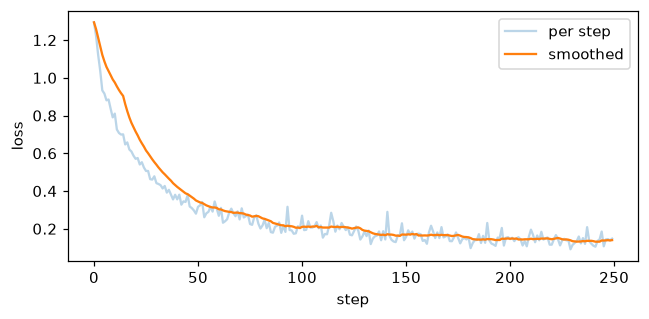

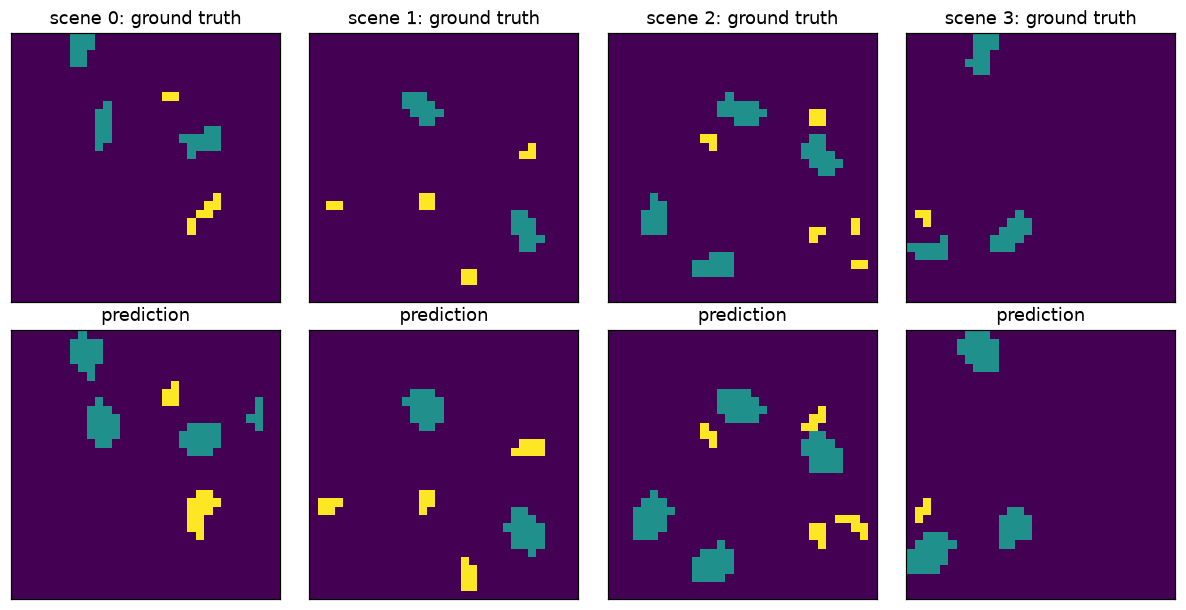

In [14]:
plt.figure(figsize=(6, 3))
plt.plot(trainer.history.losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

tb = test_batches[0]
pred = trainer.predict(tb)
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s}: ground truth")
    ax[1, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Does it really use the geometry? 🔬
Keep images and labels fixed, but **rotate the camera extrinsics by 90°**. A lifter that truly maps pixels to the world through
the calibration must now fail. (`lifting-verify` does this for every lifter.)

In [15]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0     # 90 degrees about z
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU, correct extrinsics: {good:.3f}")
print(f"mIoU, rotated extrinsics: {bad:.3f}   -> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

mIoU, correct extrinsics: 0.500
mIoU, rotated extrinsics: 0.018   -> drops by 96%


## Step 9: Recap, pros and cons, exercises

**Pros:** no depth head, no attention, almost no parameters in the lifter, fast, never leaves holes in the visible region.
**Cons:** no notion of depth ⇒ each feature is smeared along its ray; occlusion is ignored (a voxel *behind* a car reads the car's pixel).

```
image features ─► for each voxel: project centre ─► bilinear read ─► mean over seeing cameras ─► fold Z into channels ─► conv ─► BEV
```

### 🧪 Exercises
1. In Step 5 use `red` for **blue** (pedestrian) pixels. Pedestrians are small. Does the streak look different?
2. Change `level=0` to `level=1` (coarser feature map) in `build_bev_model("simple_bev", ..., level=1)`. Speed vs. mIoU?
3. Use `GridSpec(resolution=(32, 32, 8))`. More height layers means more channels in the compressor; does mIoU change?
4. Replace `masked_camera_mean` by `max` over cameras. How do the streaks of Step 5 change?
5. Compare with `depth_warp` (next notebook): same pulling, but through a depth-weighted frustum.